<a href="https://colab.research.google.com/github/anshulsharma200817-svg/data_analyticsusingpythonassesments/blob/main/module5%266.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODULE 5&6 ASSIGNMENT EDA_Statistical_Analysis:  
NAME-ANSHUL SHARMA   
COURSE-DATA ANALYTICS WITH PYTHON   
SECTION-H   
ROLL NO-BETN1AI25061


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the 'tips' dataset from Seaborn
df = sns.load_dataset('tips')

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


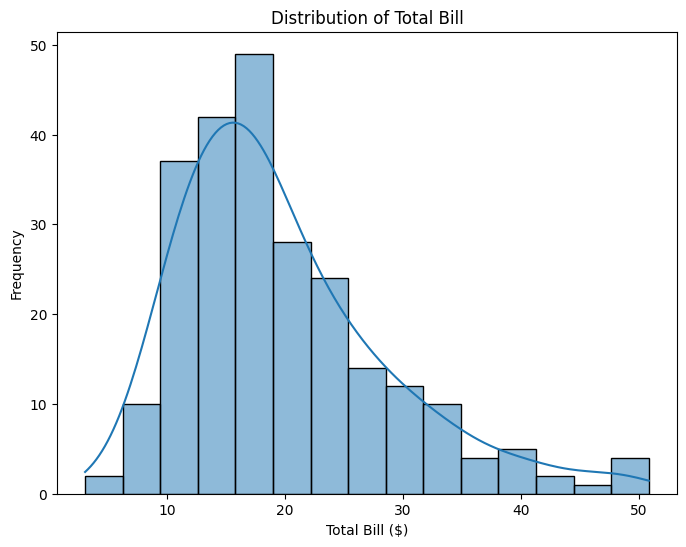

In [3]:
plt.figure(figsize=(8, 6))
sns.histplot(df['total_bill'], kde=True, bins=15)
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.show()

### Interpretation of Histogram (Total Bill)
This histogram shows the distribution of the `total_bill` amount. We can observe:
- The distribution is right-skewed, meaning most total bills are on the lower end.
- The majority of bills fall between $10 and $20.
- There are fewer instances of very high total bills.
- The peak of the distribution is around $15-$20.

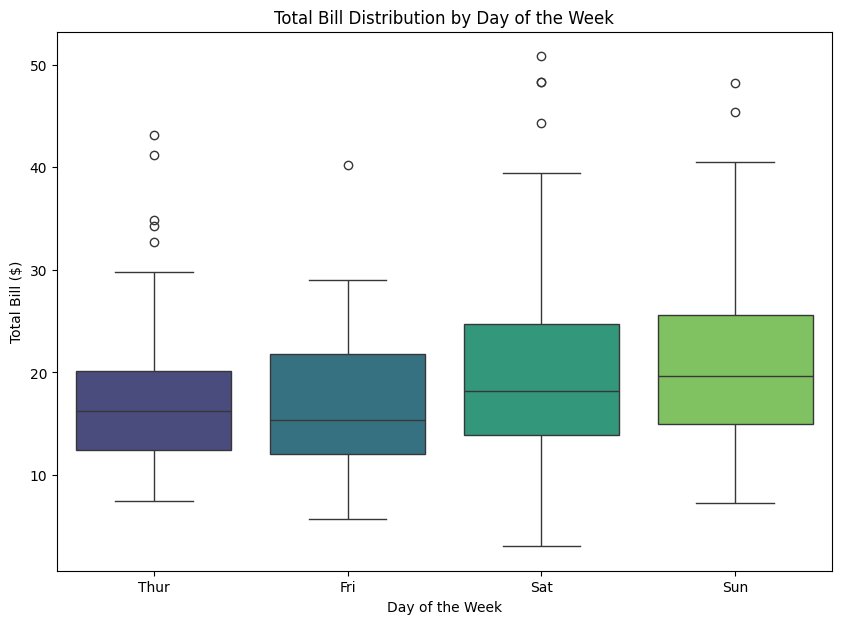

In [5]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='day', y='total_bill', data=df, palette='viridis', hue='day', legend=False)
plt.title('Total Bill Distribution by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Bill ($)')
plt.show()

### Interpretation of Boxplot (Total Bill by Day)
This boxplot illustrates the distribution of `total_bill` for each day of the week:
- **Thursday and Friday** generally have lower median total bills compared to **Saturday and Sunday**.
- **Saturday and Sunday** show higher variability (larger interquartile range) and higher median `total_bill` values, indicating busier and potentially more expensive dining experiences on weekends.
- Outliers (individual points) are visible, particularly on Saturday and Sunday, suggesting some exceptionally high bills on those days.
- The range of total bills appears broadest on Saturday and Sunday as well.

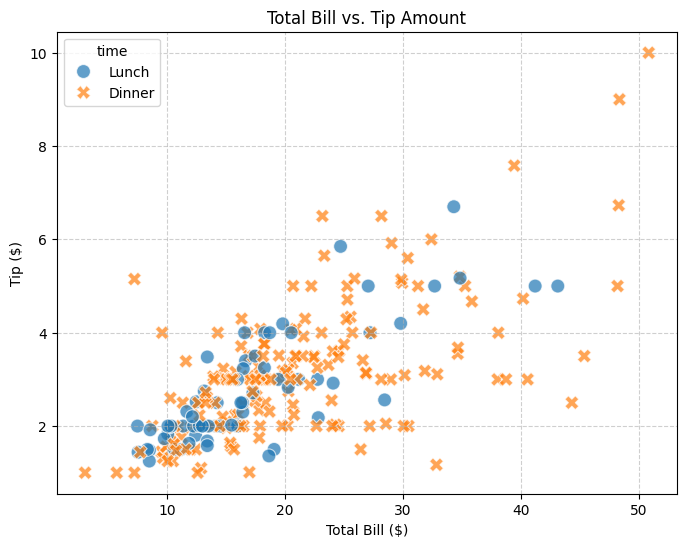

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_bill', y='tip', data=df, hue='time', style='time', s=100, alpha=0.7)
plt.title('Total Bill vs. Tip Amount')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Interpretation of Scatter Plot (Total Bill vs. Tip)
This scatter plot visualizes the relationship between `total_bill` and `tip`:
- There is a clear positive linear relationship: as the `total_bill` increases, the `tip` amount generally increases as well. This confirms the strong positive correlation observed in the heatmap.
- The spread of tips tends to increase with the total bill, meaning for higher bills, there's a wider range of tip amounts given.
- Points are colored and styled by `time` (Dinner/Lunch), suggesting that the relationship holds for both, though there might be some subtle differences in tipping patterns between lunch and dinner, with dinner generally having higher total bills and tips.

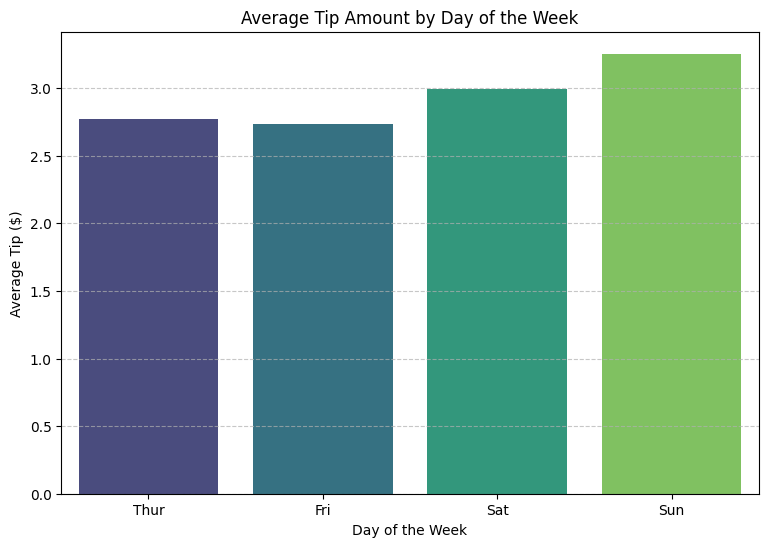

In [9]:
plt.figure(figsize=(9, 6))
sns.barplot(x='day', y='tip', data=df, estimator=lambda x: sum(x)/len(x), palette='viridis', hue='day', legend=False, errorbar=None)
plt.title('Average Tip Amount by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Tip ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of Bar Chart (Average Tip by Day)
This bar chart displays the average tip amount for each day of the week:
- **Sunday** generally has the highest average tip, followed by **Saturday**.
- **Thursday** and **Friday** show lower average tip amounts compared to the weekend days.
- This pattern aligns with the total bill distribution, where weekend days also tend to have higher total bills, suggesting that higher bills might lead to higher average tips, or that customers on weekends are more generous tippers.

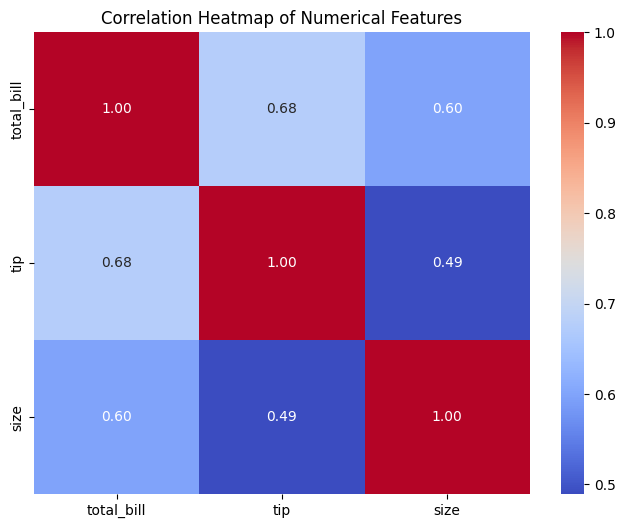

In [6]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Interpretation of Correlation Heatmap
This heatmap displays the pairwise correlation coefficients between numerical variables:
- **Total Bill and Tip:** There is a strong positive correlation (0.68) between `total_bill` and `tip`, indicating that as the total bill increases, the tip amount also tends to increase.
- **Total Bill and Size:** A moderate positive correlation (0.60) exists between `total_bill` and `size`, suggesting that larger dining parties generally incur higher total bills.
- **Tip and Size:** There is also a moderate positive correlation (0.49) between `tip` and `size`, meaning larger parties tend to leave higher tips, which aligns with higher total bills.

All correlations are positive, implying that these numerical features tend to increase together.